In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Plots

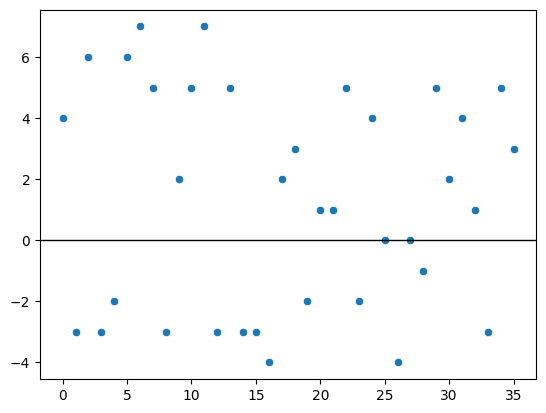

In [2]:
a1 = np.random.randint(-4, 8, size=(6,6))

# Flatten the matrix so it's easy to scatter
x = np.arange(a1.size)          # 0,1,2,...,35
vals = a1.flatten()

sns.scatterplot(x=np.arange(len(vals)),
                 y=vals)
plt.axhline(0, color='black', linewidth=1)

<Axes: ylabel='Density'>

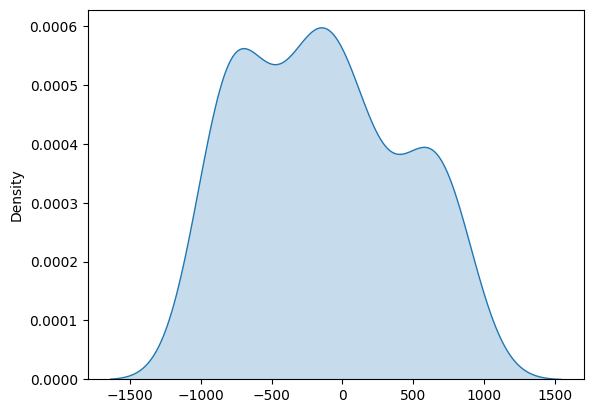

In [3]:
b1 = np.random.randint(-1000,900, size=(10,10))

vals = b1.flatten()     # convert 4x4 to 1-D array of 16 numbers

sns.kdeplot(vals,
            fill=True)

## Practice

### 1. Random shapes + .shape mind-reading

In [ ]:
a = np.random.randint(-100, 999, size=(3,4))

print(a)
print(a.shape)

[[519 211 134 890]
 [379 -37 429 607]
 [714 657 100 625]]
(3, 4)


In [ ]:
print(a.reshape(2,6))
print(a.reshape(12))      # 1-D
print(a.reshape(1,3,4))   # 3-D

### 2. Sign Accessing

In [ ]:
b = np.random.randint(-1000, 1000, size=(5,5))


print(np.sum(b < 0))
print(np.sum(b > 0))

array([[-421,  417, -757, -139, -140],
       [-430,  762, -523,  440, -486],
       [-872,  321,  680,  494, -802],
       [-347,   18,  404,  -63,  553],
       [-621,  820, -376, -409,  240],
       [ 489,    7, -150,  972,  952],
       [ 464,  393,  738,  363, -159],
       [-313,    9,  496,  405,  376],
       [ 232, -258, -110,  353,  -34],
       [ 327, -106, -656,  652, -563]])

### 2. Concatenate weird shit.

In [ ]:
x = np.random.randint(-100,100, size=(5,5))
y = np.random.randint(-100,100, size=(5,5))

print(x)
print(y)

[[ 79 -46 -93 -34 -87]
 [-35  80  20  48 -80]
 [ 96  83  85 -63 -97]
 [-61  81 -88  25  45]
 [-20  14 -15  82 -44]]
[[-25 -90 -65  87 -64]
 [-33 -98   7  -2   4]
 [ 29 -56 -32  31 -72]
 [ 28 -76  27  59  93]
 [ 68  51 -48 -79 -47]]


In [ ]:
np.concatenate([x, y], axis=0)
np.concatenate([x, y], axis=1)

array([[ 79, -46, -93, -34, -87, -25, -90, -65,  87, -64],
       [-35,  80,  20,  48, -80, -33, -98,   7,  -2,   4],
       [ 96,  83,  85, -63, -97,  29, -56, -32,  31, -72],
       [-61,  81, -88,  25,  45,  28, -76,  27,  59,  93],
       [-20,  14, -15,  82, -44,  68,  51, -48, -79, -47]])

### 3. Stack slices into 3D tensors

In [29]:
A = np.arange(12).reshape(3,4)
B = np.arange(12,24).reshape(3,4)

print(A)
print(B)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]


In [32]:
cube = np.stack([A, B], axis=0)
cube

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [33]:
cube.shape     # (2,3,4)

(2, 3, 4)

### 4. Broadcasting sorcery

In [35]:
v = np.array([1,2,3])
m = np.ones((3,3))

print(v)
print(m)

[1 2 3]
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


In [36]:
m + v

array([[2., 3., 4.],
       [2., 3., 4.],
       [2., 3., 4.]])

### 5. Flatten → scatter → see noise

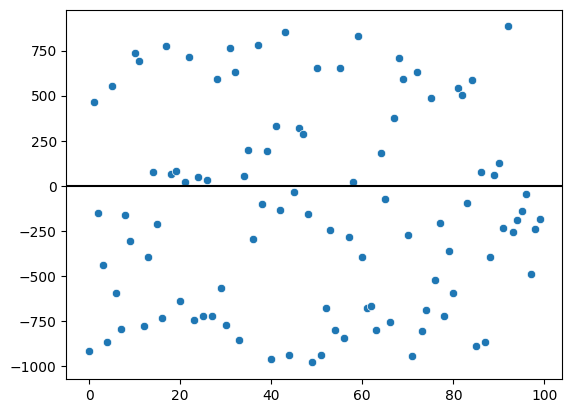

In [37]:
arr = np.random.randint(-50,50, size=(5,5))
vars = arr.flatten()

sns.scatterplot(x=np.arange(len(vals)), y=vals)
plt.axhline(0, color="black")
plt.show()

### 6. Make a 3D array and index slices

In [38]:
t = np.random.randint(0,10, size=(2,3,4))

print(t)

[[[9 6 6 7]
  [8 6 2 8]
  [0 8 6 0]]

 [[6 8 2 3]
  [9 9 6 8]
  [7 1 7 0]]]


In [39]:
print(t[0])       # first matrix
print(t[1, :, :]) # same thing explicitly
print(t[:, 1, :]) # “row 1” across all slices

[[9 6 6 7]
 [8 6 2 8]
 [0 8 6 0]]
[[6 8 2 3]
 [9 9 6 8]
 [7 1 7 0]]
[[8 6 2 8]
 [9 9 6 8]]


### 7. Rotate shapes around with transpose

In [40]:
A = np.arange(12).reshape(3,4)

print(A)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [42]:
print(A.T)
print(A.T.shape)

[[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]
(4, 3)


### 8. Do stupid arithmetic and watch shapes collide

In [44]:
np.random.randn(2,3) + np.random.randn(3,2)

ValueError: operands could not be broadcast together with shapes (2,3) (3,2) 

In [45]:
np.random.randn(2,1) + np.random.randn(1,3)


array([[ 0.54937067, -0.86597952, -1.25549108],
       [ 1.79675026,  0.38140007, -0.00811149]])

### 9. Simulate noise and plot it

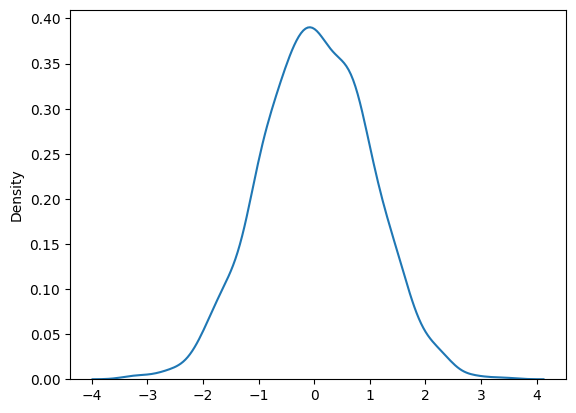

In [46]:
noise = np.random.normal(0, 1, size=1000)
sns.kdeplot(noise)
plt.show()